# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


In [5]:
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [6]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [7]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [9]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [10]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [11]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/03/21 07:12:00 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.8.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/03/21 07:12:02 INFO mlflow.tracking.fluent: Experiment with name 'ames-housing-autolog' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/1', creation_time=1774073522377, experiment_id='1', last_update_time=1774073522377, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [18]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [19]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/21 07:13:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed t


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/dfef7b6e7a964423bc72df38d4bb960e
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/eeed588e3d5a413cab55d5a6d57fdb91
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:31 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/05dfd7d203d54af395a3d50fa393e291
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:13:33 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:34 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:35 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:36 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:37 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:38 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/b833c4f477e043808a023dd9389ab812
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:13:38 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:13:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/cb29843de33e40c3842ab3c39dbd2d9f
🧪 View experiment at: http://localhost:5001/#/experiments/1


Open the MLflow dashboard at http://localhost:5000/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [21]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: 81d5fa07ed579e6ab17f915b0b12d1db
File size: 163639 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [22]:
# Connect to MLflow tracking server
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


In [23]:
# Load and prepare the Ames Housing dataset with train/test split by year
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# Chronological split: 2006-2007 for training, 2008 for testing
df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [24]:
# Build preprocessing pipelines for numerical and categorical features
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

2026/03/21 07:36:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5fc549d2ad7048f3b5cc9d1266a22257', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/21 07:36:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/03/21 07:36:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '709b20ec4b2c45dc956b9674c544db22', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/21 07:36:04 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


🏃 View run bouncy-mule-276 at: http://localhost:5001/#/experiments/1/runs/5fc549d2ad7048f3b5cc9d1266a22257
🧪 View experiment at: http://localhost:5001/#/experiments/1
🏃 View run learned-ray-195 at: http://localhost:5001/#/experiments/1/runs/709b20ec4b2c45dc956b9674c544db22
🧪 View experiment at: http://localhost:5001/#/experiments/1


In [25]:
# Verify dataset dimensions after preprocessing
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


In [26]:
# Enable MLflow autologging for scikit-learn and create experiment
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/03/21 07:36:52 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.8.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/1', creation_time=1774073522377, experiment_id='1', last_update_time=1774073522377, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [28]:
# Define 5 baseline scikit-learn models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [29]:
# Training function with cross-validation, metrics logging, and optional DVC metadata
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test, dvc_metadata=None):
    results = {}

    for model_name, model in models:
        with mlflow.start_run(run_name=model_name):
            # Log DVC metadata for data versioning audit trail
            if dvc_metadata:
                mlflow.log_param("data_md5", dvc_metadata["md5"])
                mlflow.log_param("data_size", dvc_metadata["size"])
                mlflow.log_param("data_path", dvc_metadata["path"])

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # Log custom cross-validation metrics
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [30]:
# Run baseline models without DVC metadata
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/21 07:38:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:38:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:38:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.895 ± 0.035
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/42bc91737ae640238d0fe6ef19f5bd1a
🧪 View experiment at: http://localhost:5001/#/experiments/1

Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.755 ± 0.057
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/97cd969314a84a49aee2c0fe684154fc
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:38:05 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 38324.60
  MAE: 26033.27
  R^2: 0.743
  CV R^2 (mean ± std): 0.691 ± 0.049
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/6464aedcf6804b918de9ca447c94b3fa
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:38:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 25814.13
  MAE: 15606.16
  R^2: 0.883
  CV R^2 (mean ± std): 0.879 ± 0.049
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/90233962034f4831ad91a75b91756319
🧪 View experiment at: http://localhost:5001/#/experiments/1

Gradient Boosting:
  RMSE: 21600.50
  MAE: 13840.01
  R^2: 0.918
  CV R^2 (mean ± std): 0.904 ± 0.031
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/e75264eb11b342b69fa78da2ee00bda3
🧪 View experiment at: http://localhost:5001/#/experiments/1


In [31]:
# Read DVC metadata to link data version with MLflow experiments
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)

    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: 81d5fa07ed579e6ab17f915b0b12d1db
File size: 163639 bytes
Data path: ames_data_2006_2008.parquet


In [32]:
# Define 5 new scikit-learn models with different algorithms and parameters
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.svm import SVR

models_v2 = [
    ("Lasso Regression", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, random_state=42)),
    ("Extra Trees", ExtraTreesRegressor(n_estimators=100, random_state=42)),
    ("SVR", SVR(kernel="rbf", C=100)),
]

In [33]:
# Run new models with DVC metadata logging for data versioning audit trail
dvc_metadata = get_dvc_metadata("data/ames_data_2006_2008.parquet.dvc")
fit_sklearn_models_with_cv(models_v2, X_train, X_test, y_train, y_test, dvc_metadata)

2026/03/21 07:39:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/21 07:39:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Lasso Regression:
  RMSE: 24077.53
  MAE: 16759.25
  R^2: 0.899
  CV R^2 (mean ± std): 0.867 ± 0.074
🏃 View run Lasso Regression at: http://localhost:5001/#/experiments/1/runs/613ba6a46e164d19af8cecf86b53f733
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:39:49 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



ElasticNet:
  RMSE: 27319.47
  MAE: 18594.52
  R^2: 0.869
  CV R^2 (mean ± std): 0.843 ± 0.027
🏃 View run ElasticNet at: http://localhost:5001/#/experiments/1/runs/15a15aa5ffa54b03a3b82f28b60ba8f6
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:39:51 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



AdaBoost:
  RMSE: 32704.28
  MAE: 23665.54
  R^2: 0.813
  CV R^2 (mean ± std): 0.830 ± 0.058
🏃 View run AdaBoost at: http://localhost:5001/#/experiments/1/runs/f732e29b506c45f7aab9242994d80374
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/21 07:39:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Extra Trees:
  RMSE: 23448.54
  MAE: 14918.67
  R^2: 0.904
  CV R^2 (mean ± std): 0.889 ± 0.042
🏃 View run Extra Trees at: http://localhost:5001/#/experiments/1/runs/5a8d0357aefe4da4b8cb3e966e26e12a
🧪 View experiment at: http://localhost:5001/#/experiments/1

SVR:
  RMSE: 74502.21
  MAE: 51817.26
  R^2: 0.029
  CV R^2 (mean ± std): -0.029 ± 0.068
🏃 View run SVR at: http://localhost:5001/#/experiments/1/runs/42f2d395f1bc4fedbe8628c9e97a7609
🧪 View experiment at: http://localhost:5001/#/experiments/1


## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

2026/03/21 07:45:11 INFO mlflow.tracking.fluent: Experiment with name 'pytorch-housing-manual' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/bartlomiejcich/MLops_lab2_versioning/mlflow-artifacts/2', creation_time=1774075511659, experiment_id='2', last_update_time=1774075511659, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

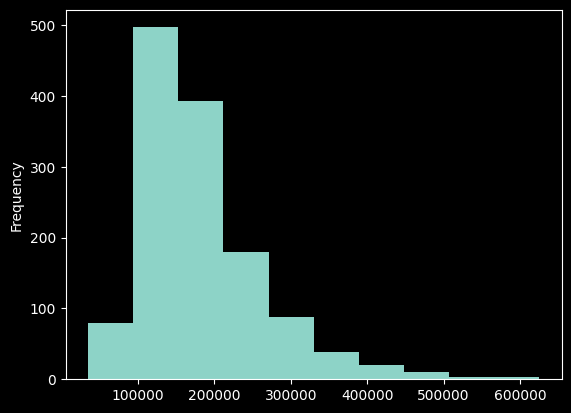

In [35]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

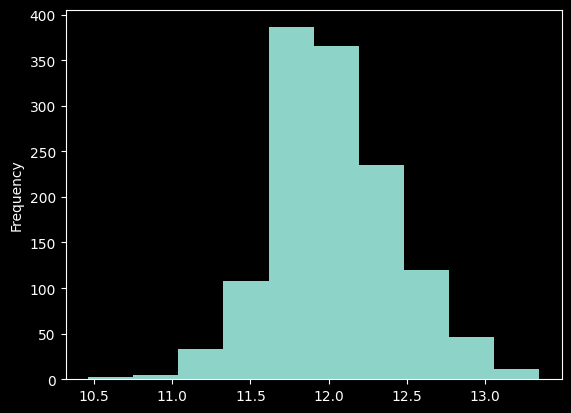

In [36]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [37]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [40]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [41]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [42]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 34256.51, MAE: 25974.51 R^2: 0.837

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26599.18, MAE: 18070.39 R^2: 0.884

Training Fold 3/5...
  Fold 3 Validation - RMSE: 42511.61, MAE: 33523.25 R^2: 0.731

Training Fold 4/5...
  Fold 4 Validation - RMSE: 61131.95, MAE: 40975.49 R^2: 0.346

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26843.88, MAE: 18951.45 R^2: 0.876

Cross-validation complete. Mean R^2: 0.735 (+/- 0.202)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.735 (+/- 0.202)

Cross-Validation Performance:
  R^2: 0.900
  RMSE: 23854.22
  MAE: 16551.20
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/ba7248c3f0b14b28b4476ca8f41247f5
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 23854.216796875,
 'mae': 16551.1953125,
 'r2': 0.9004104733467102,
 'cv_r2_mean': np.float64(0.7348063588142395),
 'cv_r2_std': np.float64(0.20197453079214614),
 'cv_scores': [0.8373901844024658,
  0.8840327262878418,
  0.7307586073875427,
  0.3459089994430542,
  0.875941276550293]}

### Experiment 1: first_run (baseline)
Results: Test R² 0.900, CV R² 0.735 ± 0.202. High variance between folds indicates overfitting. The network (128 units) may be too large for 1312 samples. Next step: try a smaller network.

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


In [45]:
# Experiment 2: Smaller network to reduce overfitting
experiment_config = {
    "name": "02_small_network_64",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 200,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 02_small_network_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 21935.88, MAE: 15403.10 R^2: 0.933

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19578.70, MAE: 12941.87 R^2: 0.937

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26547.47, MAE: 17300.36 R^2: 0.895

Training Fold 4/5...
  Fold 4 Validation - RMSE: 59678.25, MAE: 47229.94 R^2: 0.377

Training Fold 5/5...
  Fold 5 Validation - RMSE: 43463.01, MAE: 34902.91 R^2: 0.675

Cross-validation complete. Mean R^2: 0.763 (+/- 0.216)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.763 (+/- 0.216)

Cross-Validation Performance:
  R^2: 0.908
  RMSE: 22912.18
  MAE: 15583.19
Test Set Performance:
FINAL RESULTS for 02_small_network_64:

🏃 View run 02_small_network_64 at: http://localhost:5001/#/experiments/2/runs/86d779d7c7c549ef90b861d3bf823ca4
🧪 View experiment at: http://

### Experiment 2: 02_small_network_64
Results: Test R² 0.908, CV R² 0.763 ± 0.216. Smaller network improved test R², but CV variance is still high (Fold 4: 0.377). The learning rate (0.01) may be causing instability. Next step: lower learning rate to stabilize training.

In [46]:
# Experiment 3: Lower learning rate to stabilize training
experiment_config = {
    "name": "03_stable_lr_005",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.005,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 03_stable_lr_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24499.50, MAE: 18353.63 R^2: 0.917

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23365.97, MAE: 15456.38 R^2: 0.911

Training Fold 3/5...
  Fold 3 Validation - RMSE: 43706.09, MAE: 33190.45 R^2: 0.715

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31619.58, MAE: 23550.26 R^2: 0.825

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26493.35, MAE: 18698.53 R^2: 0.879

Cross-validation complete. Mean R^2: 0.849 (+/- 0.074)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.849 (+/- 0.074)

Cross-Validation Performance:
  R^2: 0.904
  RMSE: 23386.91
  MAE: 15372.62
Test Set Performance:
FINAL RESULTS for 03_stable_lr_005:

🏃 View run 03_stable_lr_005 at: http://localhost:5001/#/experiments/2/runs/773a2fcd58164f6087b8e4839294c584
🧪 View experiment at: http://localhost

### Experiment 3: 03_stable_lr_005
Results: Test R² 0.904, CV R² 0.849 ± 0.074. Lower learning rate significantly stabilized training — CV std dropped from 0.216 to 0.074. However, Fold 3 is still weaker (0.715). Next step: increase dropout to improve generalization.

In [47]:
# Experiment 4: Increase dropout to improve generalization
experiment_config = {
    "name": "04_more_dropout_03",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 04_more_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 26326.93, MAE: 18461.77 R^2: 0.904

Training Fold 2/5...
  Fold 2 Validation - RMSE: 20716.66, MAE: 13437.54 R^2: 0.930

Training Fold 3/5...
  Fold 3 Validation - RMSE: 33539.11, MAE: 22941.82 R^2: 0.832

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27893.27, MAE: 19107.94 R^2: 0.864

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23645.22, MAE: 16391.06 R^2: 0.904

Cross-validation complete. Mean R^2: 0.887 (+/- 0.034)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.887 (+/- 0.034)

Cross-Validation Performance:
  R^2: 0.905
  RMSE: 23275.99
  MAE: 16273.91
Test Set Performance:
FINAL RESULTS for 04_more_dropout_03:

🏃 View run 04_more_dropout_03 at: http://localhost:5001/#/experiments/2/runs/b7be8c760c0d40b5a640bcfa4f7a4306
🧪 View experiment at: http://loc

### Experiment 4: 04_more_dropout_03
Results: Test R² 0.905, CV R² 0.887 ± 0.034. Best CV result so far — increased dropout improved both mean and stability. All folds above 0.83. Next step: increase epochs to give the model more training time.

In [48]:
# Experiment 5: More epochs to improve convergence
experiment_config = {
    "name": "05_more_epochs_400",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 05_more_epochs_400...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 23018.99, MAE: 15327.11 R^2: 0.927

Training Fold 2/5...
  Fold 2 Validation - RMSE: 22398.58, MAE: 13845.55 R^2: 0.918

Training Fold 3/5...
  Fold 3 Validation - RMSE: 27230.55, MAE: 18002.31 R^2: 0.890

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26420.63, MAE: 16549.95 R^2: 0.878

Training Fold 5/5...
  Fold 5 Validation - RMSE: 29436.94, MAE: 21590.25 R^2: 0.851

Cross-validation complete. Mean R^2: 0.893 (+/- 0.027)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.893 (+/- 0.027)

Cross-Validation Performance:
  R^2: 0.908
  RMSE: 22957.09
  MAE: 15551.28
Test Set Performance:
FINAL RESULTS for 05_more_epochs_400:

🏃 View run 05_more_epochs_400 at: http://localhost:5001/#/experiments/2/runs/cd5d6c5cca034bf38b9f81a9df68efbc
🧪 View experiment at: http://loc

### Experiment 5: 05_more_epochs_400
Results: Test R² 0.908, CV R² 0.893 ± 0.027. Slight improvement in both mean and stability. Model benefits from longer training. Next step: try smaller batch size (16) for more gradient updates per epoch.

In [49]:
# Experiment 6: Smaller batch size for more frequent weight updates
experiment_config = {
    "name": "06_small_batch_16",
    "hidden_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 16,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 06_small_batch_16...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24448.04, MAE: 16353.74 R^2: 0.917

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21305.36, MAE: 15521.07 R^2: 0.926

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25640.14, MAE: 16454.03 R^2: 0.902

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30839.75, MAE: 20764.32 R^2: 0.834

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25796.33, MAE: 18169.01 R^2: 0.885

Cross-validation complete. Mean R^2: 0.893 (+/- 0.033)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.893 (+/- 0.033)

Cross-Validation Performance:
  R^2: 0.883
  RMSE: 25889.86
  MAE: 17814.98
Test Set Performance:
FINAL RESULTS for 06_small_batch_16:

🏃 View run 06_small_batch_16 at: http://localhost:5001/#/experiments/2/runs/dfb68b215a544f4cb39c640f6bfb79a6
🧪 View experiment at: http://localh

### Experiment 6: 06_small_batch_16
Results: Test R² 0.883, CV R² 0.893 ± 0.033. Smaller batch did not improve results — test R² slightly decreased. Next step: try slightly larger network (96 units) with proven stable parameters (batch 32, lr 0.005, dropout 0.3).

In [50]:
# Experiment 7: Slightly larger network (96 units) with best stable parameters
experiment_config = {
    "name": "07_medium_network_96",
    "hidden_units": 96,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 07_medium_network_96...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 23040.00, MAE: 15863.41 R^2: 0.926

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31321.48, MAE: 20778.66 R^2: 0.839

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23956.05, MAE: 15795.95 R^2: 0.915

Training Fold 4/5...
  Fold 4 Validation - RMSE: 24698.57, MAE: 15472.75 R^2: 0.893

Training Fold 5/5...
  Fold 5 Validation - RMSE: 21976.10, MAE: 15077.86 R^2: 0.917

Cross-validation complete. Mean R^2: 0.898 (+/- 0.031)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.898 (+/- 0.031)

Cross-Validation Performance:
  R^2: 0.913
  RMSE: 22281.38
  MAE: 15409.85
Test Set Performance:
FINAL RESULTS for 07_medium_network_96:

🏃 View run 07_medium_network_96 at: http://localhost:5001/#/experiments/2/runs/c907c858eefb488aa751aed27c91ed99
🧪 View experiment at: http

### Experiment 7: 07_medium_network_96
Results: Test R² 0.913, CV R² 0.898 ± 0.031. Best result so far — slightly larger network improved test performance while maintaining stability. Next step: try slightly lower dropout (0.25) to see if less regularization helps.

In [51]:
# Experiment 8: Slightly lower dropout to reduce regularization
experiment_config = {
    "name": "08_lower_dropout_025",
    "hidden_units": 96,
    "dropout": 0.25,
    "learning_rate": 0.005,
    "epochs": 400,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 08_lower_dropout_025...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 26769.02, MAE: 18368.81 R^2: 0.901

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19348.03, MAE: 14043.79 R^2: 0.939

Training Fold 3/5...
  Fold 3 Validation - RMSE: 24573.12, MAE: 16428.96 R^2: 0.910

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23603.51, MAE: 15380.97 R^2: 0.902

Training Fold 5/5...
  Fold 5 Validation - RMSE: 21894.54, MAE: 14989.97 R^2: 0.917

Cross-validation complete. Mean R^2: 0.914 (+/- 0.014)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.914 (+/- 0.014)

Cross-Validation Performance:
  R^2: 0.873
  RMSE: 26917.87
  MAE: 19815.74
Test Set Performance:
FINAL RESULTS for 08_lower_dropout_025:

🏃 View run 08_lower_dropout_025 at: http://localhost:5001/#/experiments/2/runs/c183e50848094b0fa0320869a2af8a0d
🧪 View experiment at: http

### Experiment 8: 08_lower_dropout_025
Results: Test R² 0.873, CV R² 0.914 ± 0.014. Best CV stability so far (std 0.014), but test R² dropped. The model may need more training time with lower dropout. Next step: increase epochs to 500.

In [52]:
# Experiment 9: More epochs with best CV configuration
experiment_config = {
    "name": "09_more_epochs_500",
    "hidden_units": 96,
    "dropout": 0.25,
    "learning_rate": 0.005,
    "epochs": 500,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 09_more_epochs_500...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 25373.37, MAE: 16416.07 R^2: 0.911

Training Fold 2/5...
  Fold 2 Validation - RMSE: 30415.37, MAE: 18535.65 R^2: 0.848

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25128.30, MAE: 16115.39 R^2: 0.906

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30768.98, MAE: 19647.83 R^2: 0.834

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23847.66, MAE: 16333.46 R^2: 0.902

Cross-validation complete. Mean R^2: 0.880 (+/- 0.032)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.880 (+/- 0.032)

Cross-Validation Performance:
  R^2: 0.901
  RMSE: 23805.59
  MAE: 16203.16
Test Set Performance:
FINAL RESULTS for 09_more_epochs_500:

🏃 View run 09_more_epochs_500 at: http://localhost:5001/#/experiments/2/runs/3556d83c3c964ed9814afcac57f94579
🧪 View experiment at: http://loc

### Experiment 9: 09_more_epochs_500
Results: Test R² 0.901, CV R² 0.880 ± 0.032. More epochs improved test R² from 0.873 to 0.901. Next step: final experiment combining best elements — 96 units with dropout 0.3 (from exp 7) and 500 epochs.

In [53]:
# Experiment 10: Final config combining best parameters from all experiments
experiment_config = {
    "name": "10_best_combined",
    "hidden_units": 96,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 500,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: 81d5fa07...
Starting 5-fold cross-validation for 10_best_combined...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 26255.94, MAE: 16962.70 R^2: 0.904

Training Fold 2/5...
  Fold 2 Validation - RMSE: 33905.63, MAE: 20944.46 R^2: 0.812

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25164.56, MAE: 16109.81 R^2: 0.906

Training Fold 4/5...
  Fold 4 Validation - RMSE: 36253.01, MAE: 24877.97 R^2: 0.770

Training Fold 5/5...
  Fold 5 Validation - RMSE: 42819.84, MAE: 31045.64 R^2: 0.684

Cross-validation complete. Mean R^2: 0.815 (+/- 0.084)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.815 (+/- 0.084)

Cross-Validation Performance:
  R^2: 0.792
  RMSE: 34490.85
  MAE: 22340.84
Test Set Performance:
FINAL RESULTS for 10_best_combined:

🏃 View run 10_best_combined at: http://localhost:5001/#/experiments/2/runs/beeeee5d74094eca9f3e288e0bc57be7
🧪 View experiment at: http://localhost

### Experiment 10: 10_best_combined
Results: Test R² 0.792, CV R² 0.815 ± 0.084. Surprisingly worse — combining dropout 0.3 with 500 epochs led to overfitting in some folds. Too many epochs with higher dropout caused instability.

### Overall Summary

| Experiment | Test R² | CV R² Mean | CV R² Std | Key Change |
|---|---|---|---|---|
| first_run (baseline) | 0.900 | 0.735 | 0.202 | Initial config |
| 02_small_network_64 | 0.908 | 0.763 | 0.216 | Smaller network (128→64) |
| 03_stable_lr_005 | 0.904 | 0.849 | 0.074 | Lower lr (0.01→0.005) |
| 04_more_dropout_03 | 0.905 | 0.887 | 0.034 | More dropout (0.2→0.3) |
| 05_more_epochs_400 | 0.908 | 0.893 | 0.027 | More epochs (250→400) |
| 06_small_batch_16 | 0.883 | 0.893 | 0.033 | Smaller batch (32→16) |
| **07_medium_network_96** | **0.913** | **0.898** | **0.031** | **Larger network (64→96)** |
| 08_lower_dropout_025 | 0.873 | 0.914 | 0.014 | Less dropout (0.3→0.25) |
| 09_more_epochs_500 | 0.901 | 0.880 | 0.032 | More epochs (400→500) |
| 10_best_combined | 0.792 | 0.815 | 0.084 | Combined: 96, 0.3, 500ep |

### Key Findings
1. **Network size** — reducing from 128 to 64 units helped, but 96 was the sweet spot.
2. **Learning rate** — lowering from 0.03 to 0.005 had the biggest positive impact on stability.
3. **Dropout** — 0.3 improved CV significantly, but 0.25 gave the most stable CV (std 0.014).
4. **Epochs** — 400 was optimal; 500 caused degradation with higher dropout.
5. **Best model: 07_medium_network_96** — best balance of test R² (0.913) and CV stability (0.898 ± 0.031).


### Comparison: scikit-learn vs PyTorch
- Best scikit-learn: Gradient Boosting (Test R² 0.918, CV R² 0.904 ± 0.031)
- Best PyTorch: 07_medium_network_96 (Test R² 0.913, CV R² 0.898 ± 0.031)
- Both models achieve similar performance, but Gradient Boosting is slightly better and much easier to train.

### Overfitting in first PyTorch experiment
The first_run shows clear overfitting: Test R² (0.900) vs CV R² (0.735) — a gap of 0.165. High CV std (0.202) means performance varies wildly across folds. This indicates the model memorizes specific data splits rather than learning generalizable patterns.

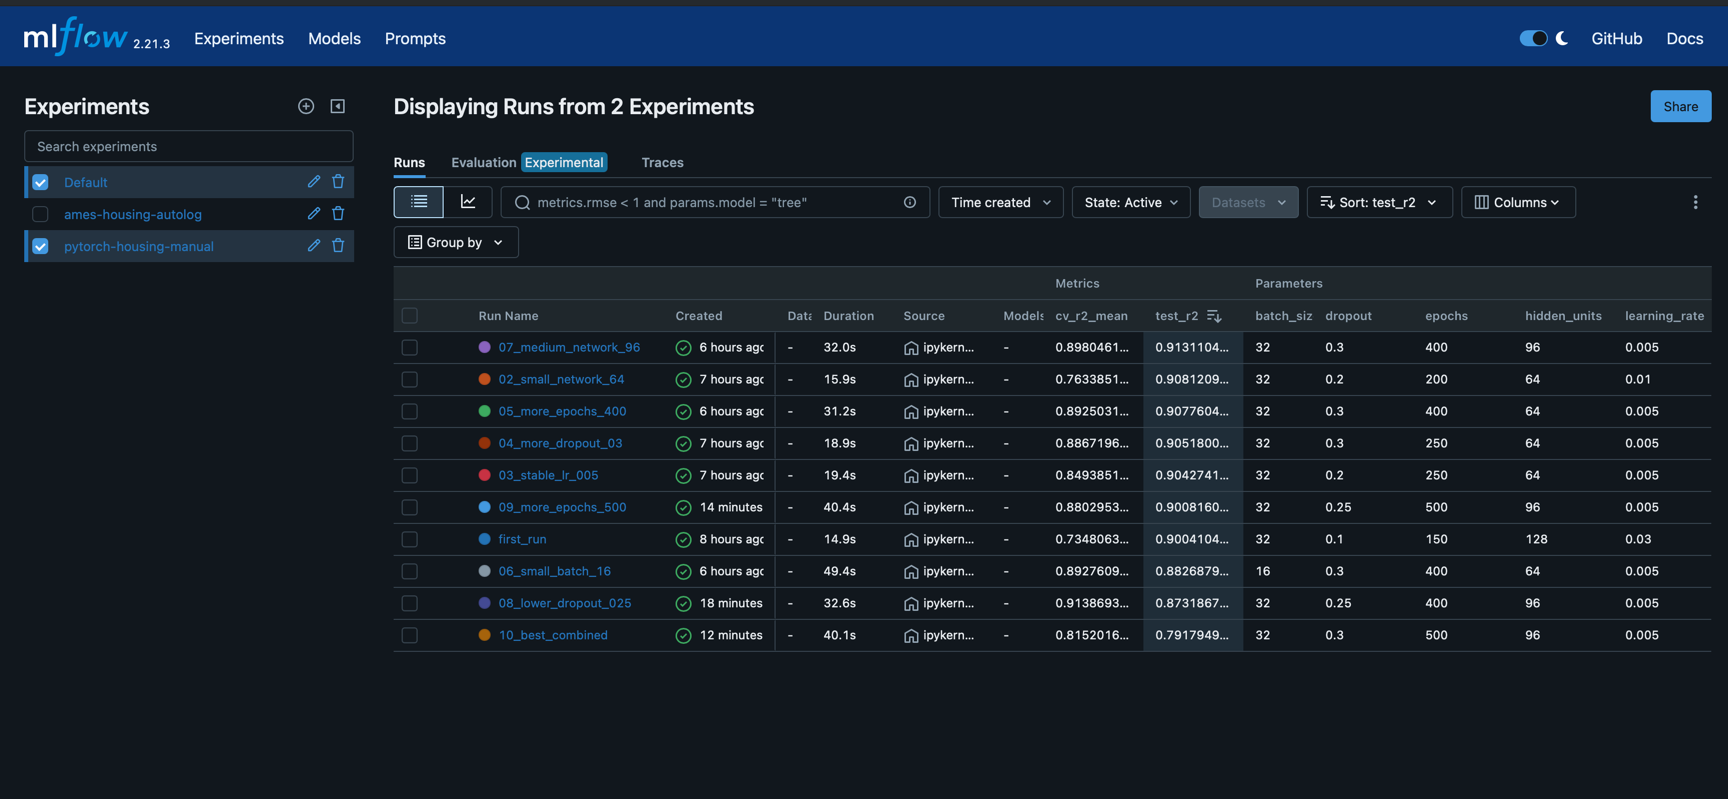

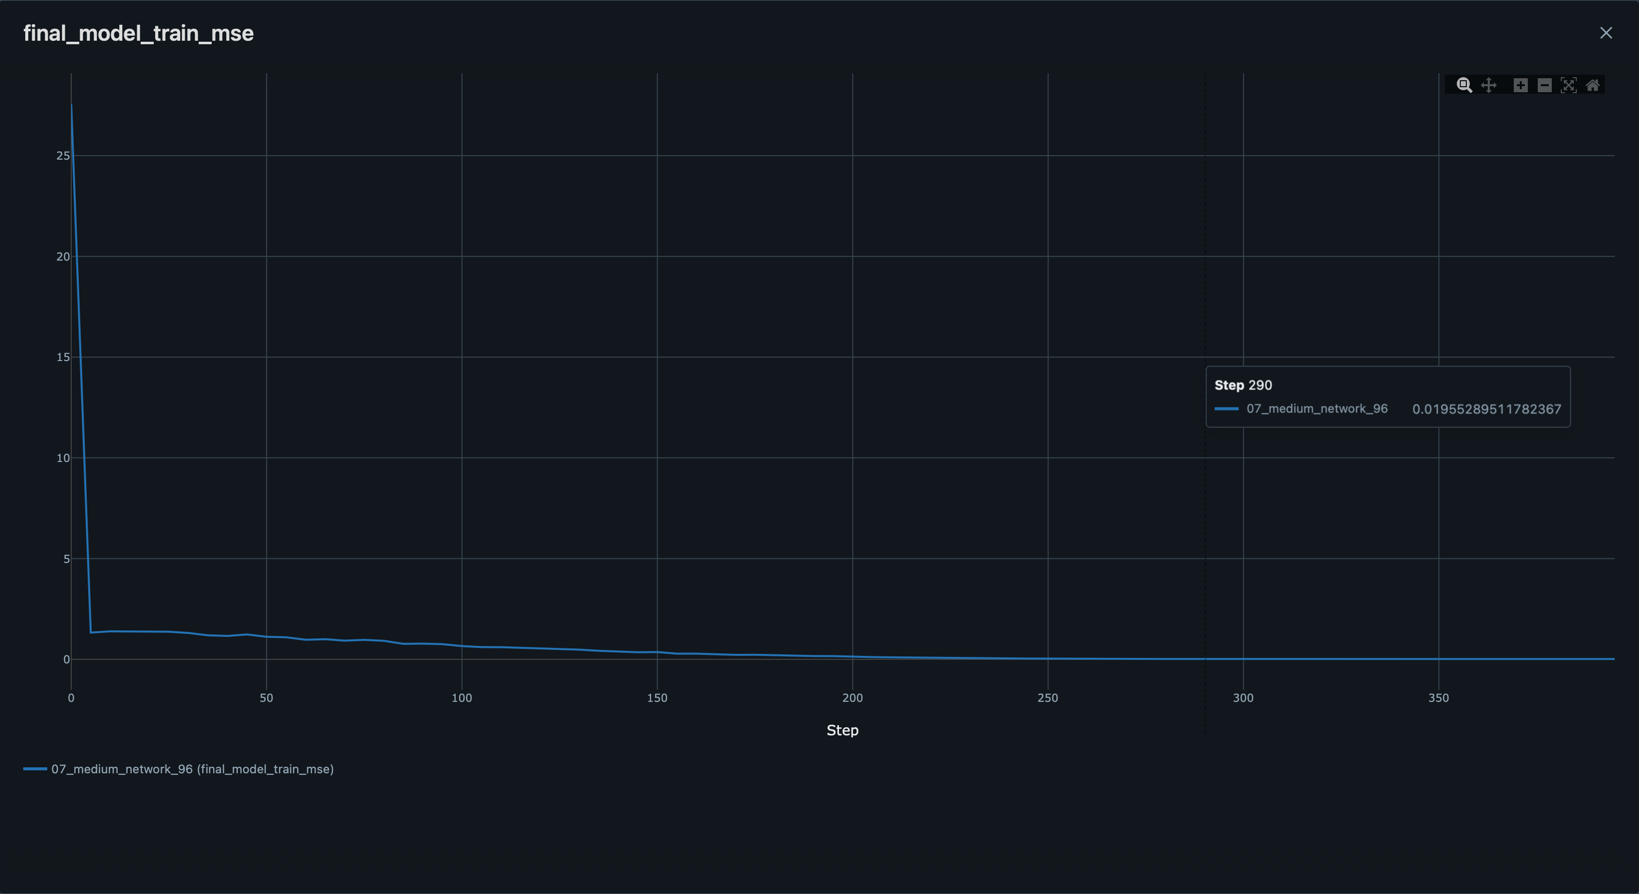

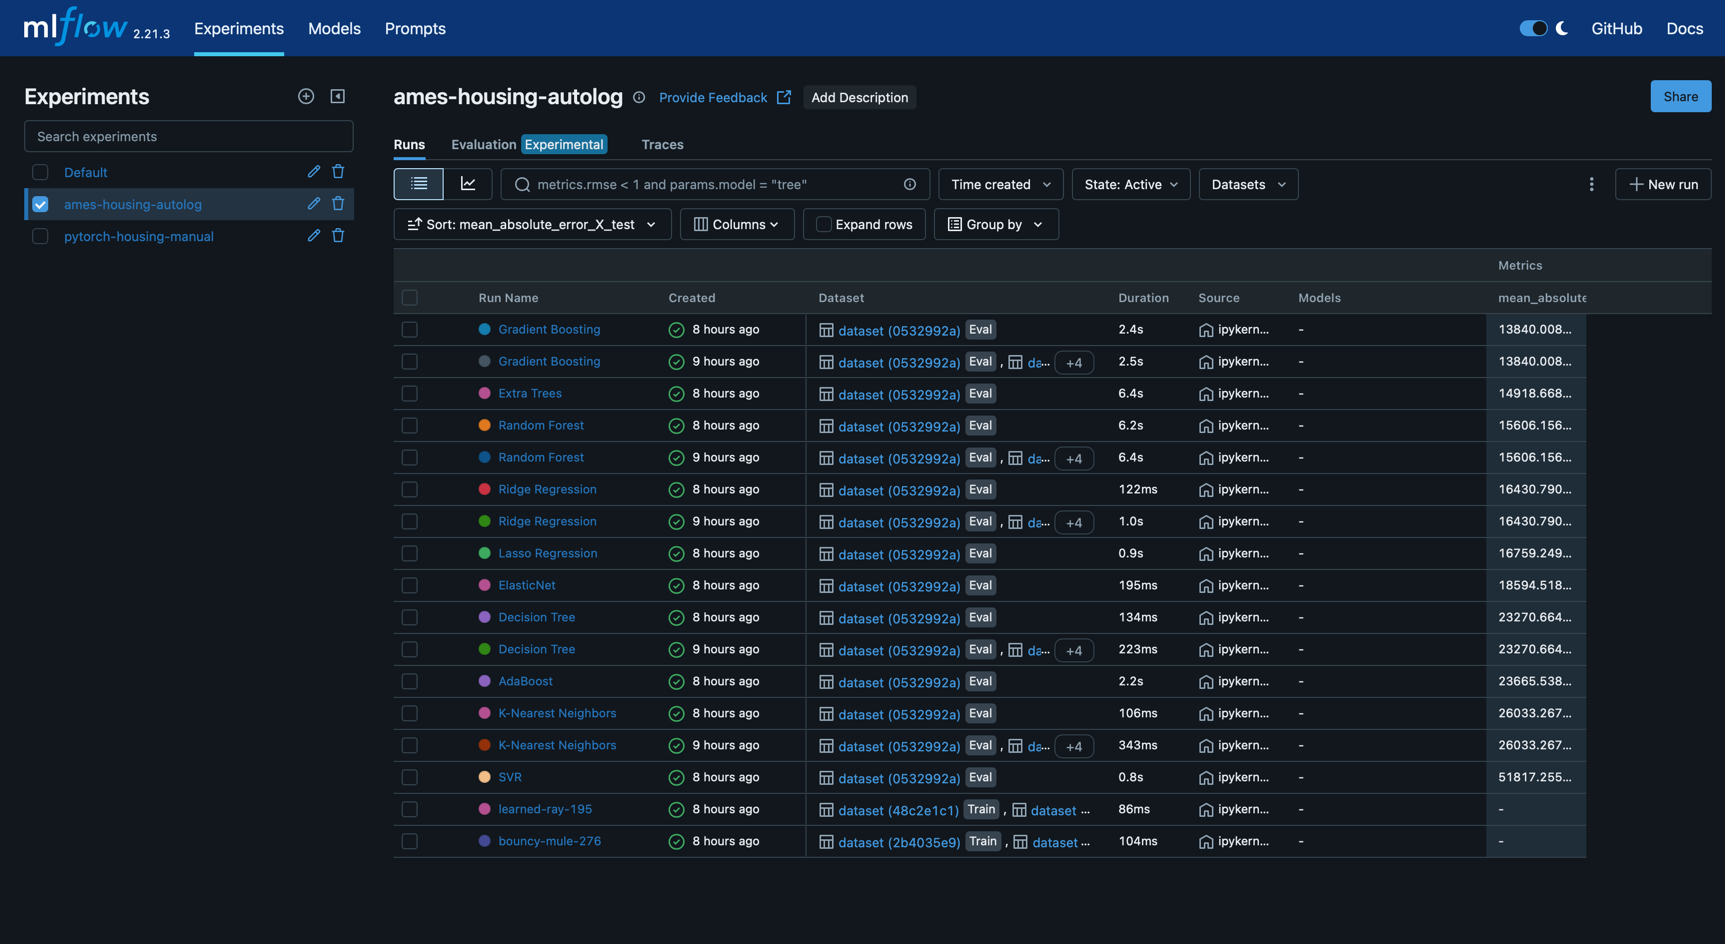

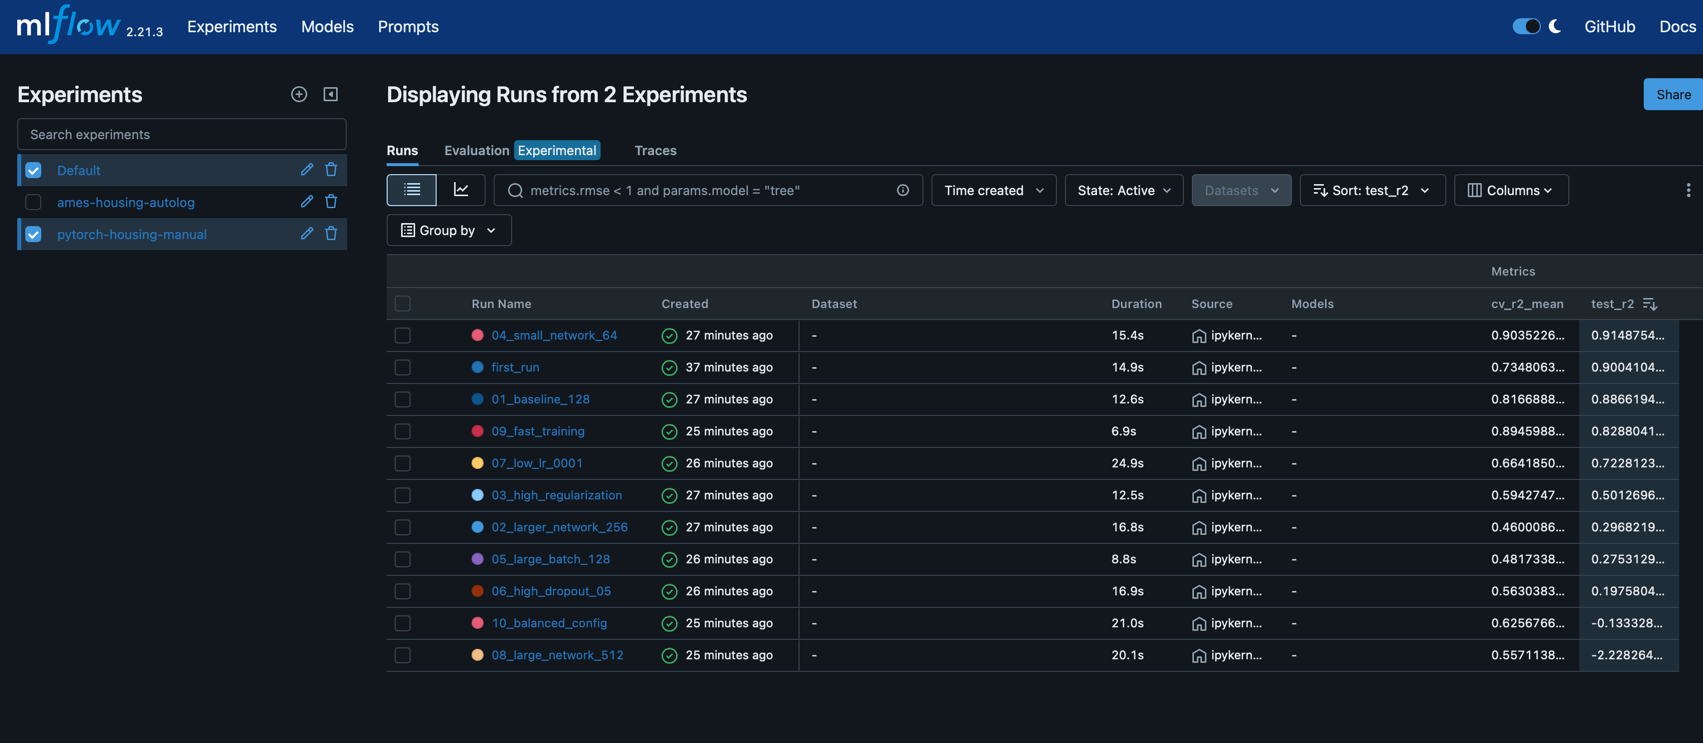

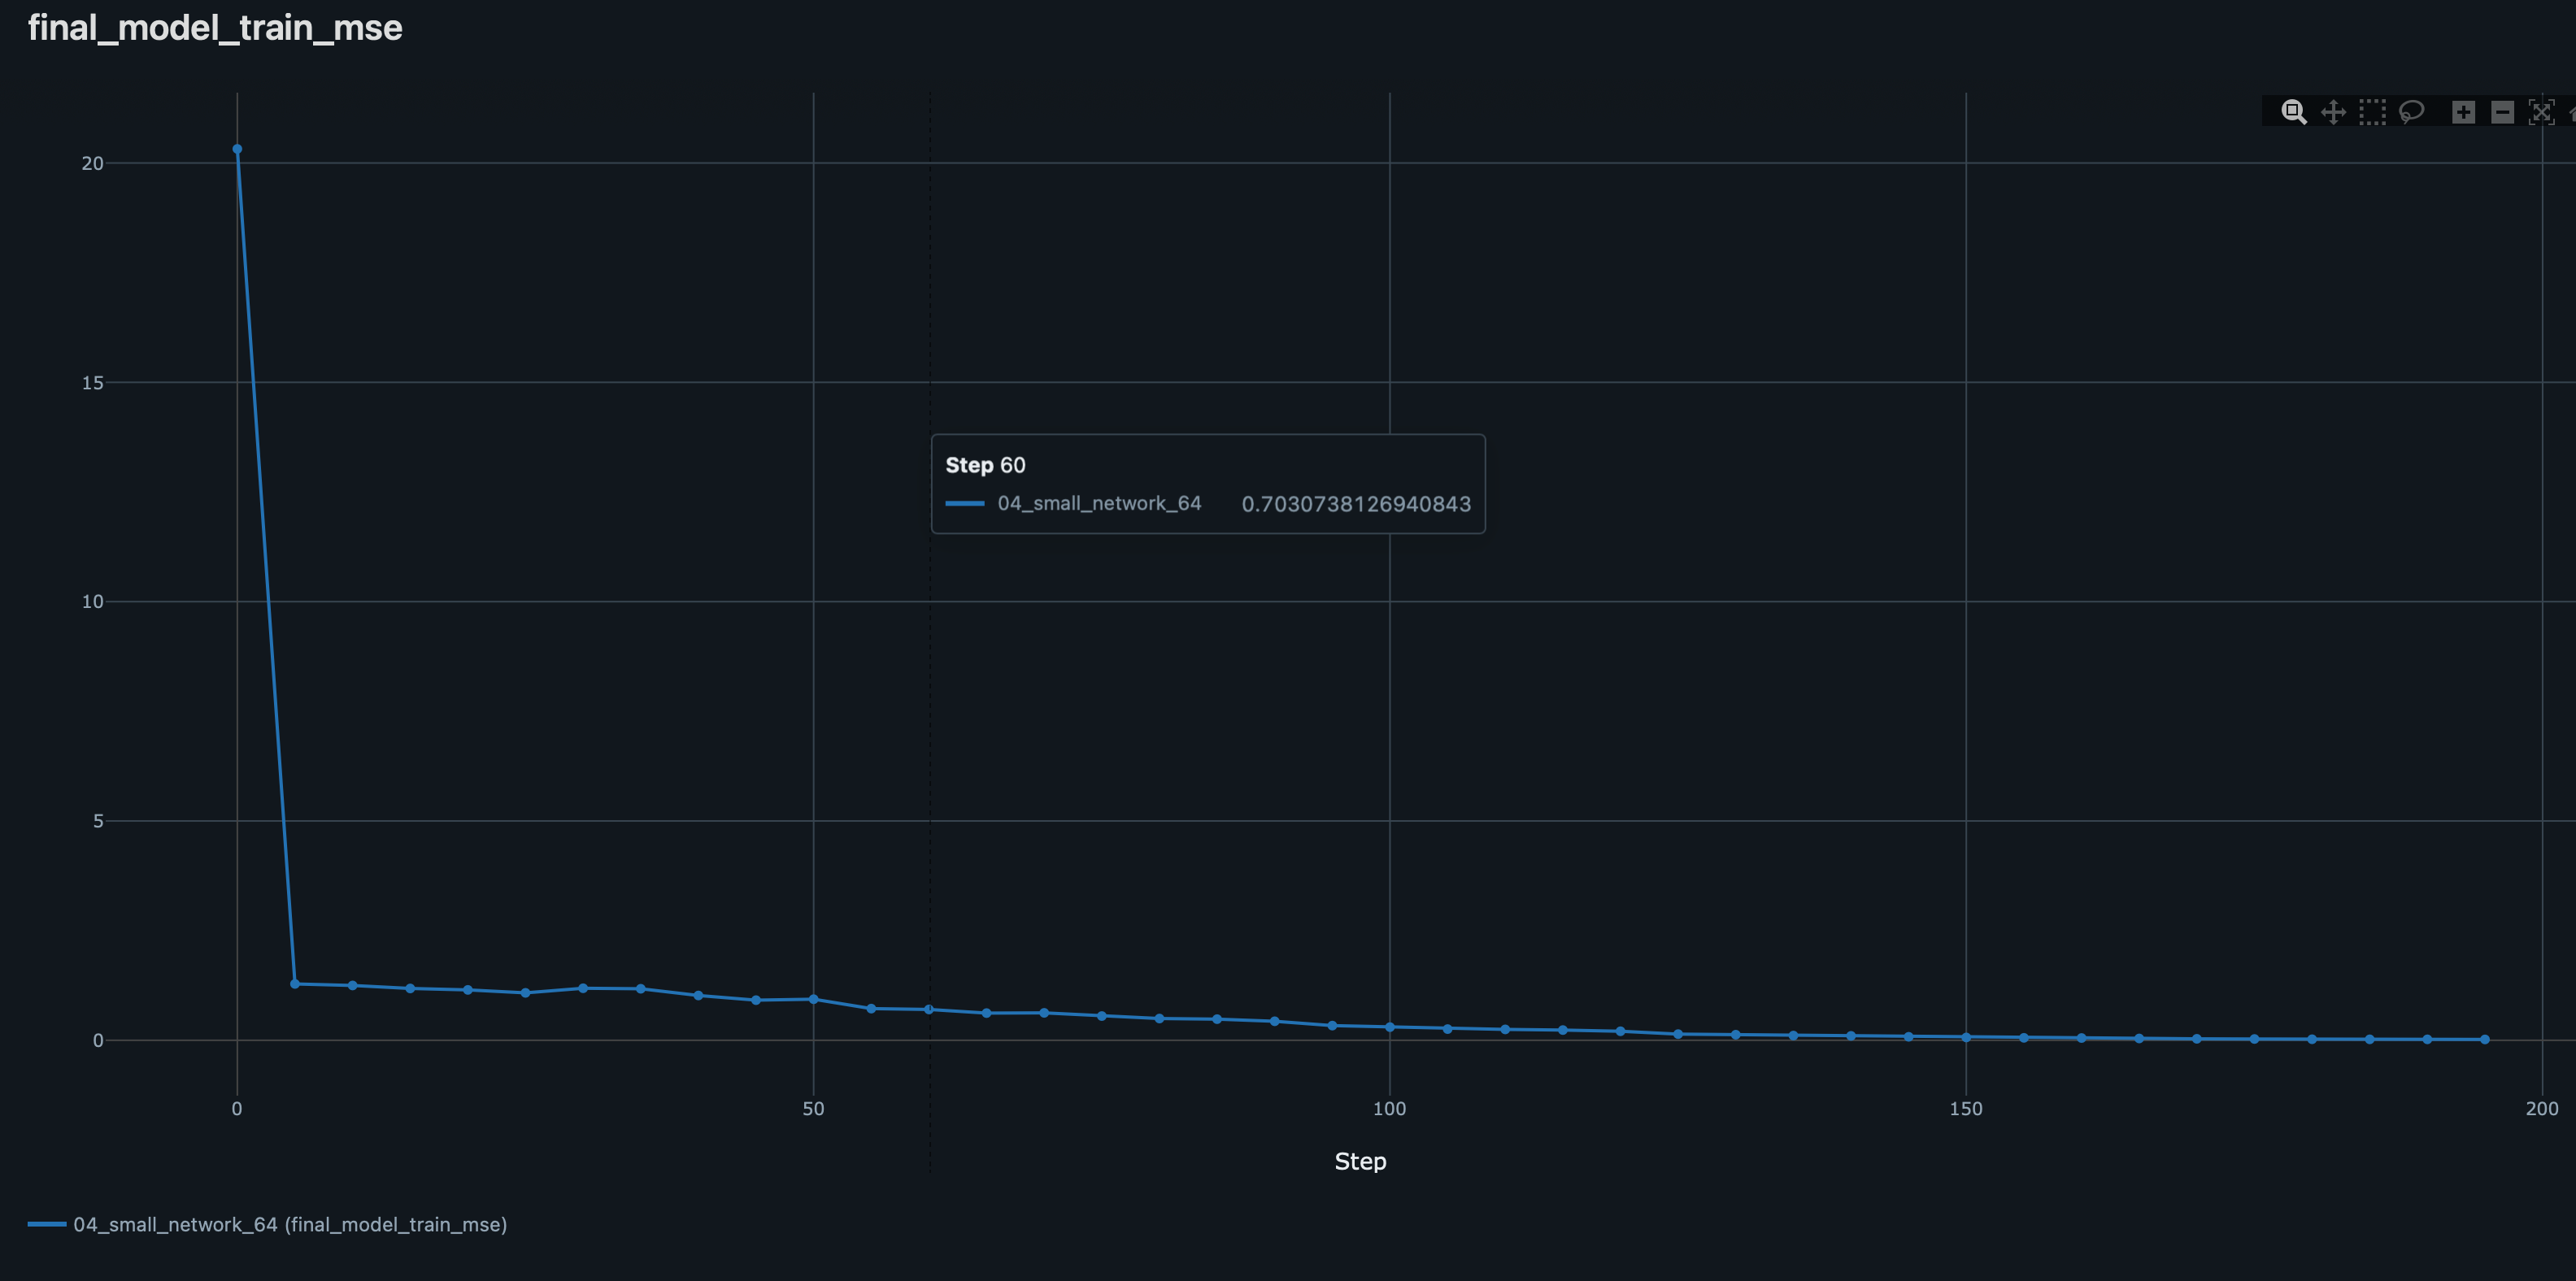

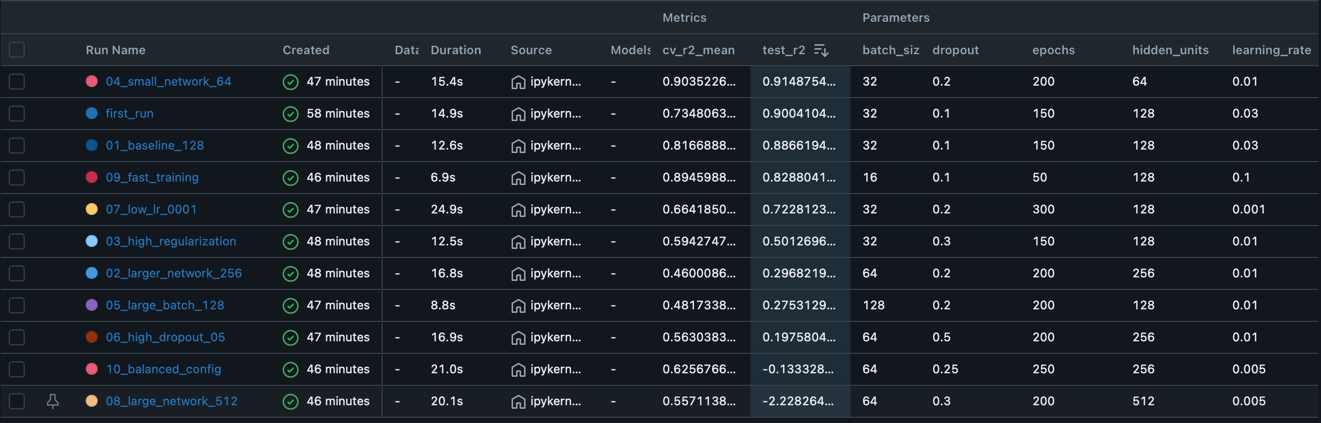

**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.
